In [1]:
import pandas as pd

path = r"E:\Midaharsyad\Upgrade Skill\Rakamin_Data Scientist_Idx Partner\Week 4\Project\loan_data_2007_2014.csv"

df = pd.read_csv(
    path,
    sep=",",
    engine="python",
    on_bad_lines="skip",
    encoding="latin1"
)

print("Loaded successfully!")
print(df.shape)

Loaded successfully!
(466285, 75)


In [3]:
#Data Understanding
df.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
#Data Understanding
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

In [7]:
#Data Cleaning
#drop kolom tidak di perlukan 
drop_cols = [
    'Unnamed: 0', 'id', 'member_id', 'url', 'zip_code', 'title', 'policy_code', 'emp_title', 'desc', 'issue_d'
]
leakage_cols = [
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
    'total_rec_int', 'total_rec_late_fee', 'recoveries',
    'collection_recovery_fee', 'last_pymnt_amnt',
    'out_prncp', 'out_prncp_inv', 
    'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d'
]

df = df.drop(columns=drop_cols + leakage_cols, errors='ignore')

In [9]:
#Data Cleaning
#drop kolom kosong
df = df.dropna(axis=1, how='all')

In [11]:
#Data Cleaning
#drop kolom dengan missing value > 50%
limit = len(df) * 0.5
df = df.dropna(thresh=limit, axis=1)

In [13]:
#Data Cleaning
print(f"Sisa kolom setelah cleaning: {df.shape[1]}")

Sisa kolom setelah cleaning: 32


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 32 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   466285 non-null  int64  
 1   funded_amnt                 466285 non-null  int64  
 2   funded_amnt_inv             466285 non-null  float64
 3   term                        466285 non-null  object 
 4   int_rate                    466285 non-null  float64
 5   installment                 466285 non-null  float64
 6   grade                       466285 non-null  object 
 7   sub_grade                   466285 non-null  object 
 8   emp_length                  445277 non-null  object 
 9   home_ownership              466285 non-null  object 
 10  annual_inc                  466281 non-null  float64
 11  verification_status         466285 non-null  object 
 12  loan_status                 466285 non-null  object 
 13  pymnt_plan    

In [17]:
#Format Data
# 1. Mengubah 'term' menjadi angka
# " 36 months" -> 36
df['term'] = df['term'].str.replace(' months', '').astype(int)

# 2. Mengubah 'emp_length' menjadi angka
# "< 1 year" jadi 0, "10+ years" jadi 10
df['emp_length'] = df['emp_length'].str.replace('\+ years', '', regex=True)
df['emp_length'] = df['emp_length'].str.replace('< 1 year', '0', regex=True)
df['emp_length'] = df['emp_length'].str.replace(' years', '', regex=True)
df['emp_length'] = df['emp_length'].str.replace(' year', '', regex=True)
df['emp_length'] = pd.to_numeric(df['emp_length'], errors='coerce').fillna(0).astype(int)

# 3. Mengubah kolom tanggal menjadi format datetime
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%y', errors='coerce')
today = pd.to_datetime('2026-03-19')
df['credit_age_months'] = ((today - df['earliest_cr_line']).dt.days / 30).fillna(0).astype(int)
df.drop(columns=['earliest_cr_line'], inplace=True, errors='ignore')

print("Formatting Selesai!")

<>:8: SyntaxWarning: invalid escape sequence '\+'
<>:8: SyntaxWarning: invalid escape sequence '\+'
C:\Users\khami\AppData\Local\Temp\ipykernel_22080\1312285490.py:8: SyntaxWarning: invalid escape sequence '\+'
  df['emp_length'] = df['emp_length'].str.replace('\+ years', '', regex=True)


Formatting Selesai!


In [19]:
#Data Cleaning
#Missing value
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

print("Kolom dengan Missing Value:")
print(missing_data)
print("\nPersentase Missing Value (%):")
print((missing_data / len(df)) * 100)

Kolom dengan Missing Value:
tot_coll_amt                  70276
tot_cur_bal                   70276
total_rev_hi_lim              70276
revol_util                      340
collections_12_mths_ex_med      145
delinq_2yrs                      29
inq_last_6mths                   29
open_acc                         29
pub_rec                          29
total_acc                        29
acc_now_delinq                   29
annual_inc                        4
dtype: int64

Persentase Missing Value (%):
tot_coll_amt                  15.071469
tot_cur_bal                   15.071469
total_rev_hi_lim              15.071469
revol_util                     0.072917
collections_12_mths_ex_med     0.031097
delinq_2yrs                    0.006219
inq_last_6mths                 0.006219
open_acc                       0.006219
pub_rec                        0.006219
total_acc                      0.006219
acc_now_delinq                 0.006219
annual_inc                     0.000858
dtype: float64


In [21]:
#Exploratory Data Analysis
#Target Distribution
df['loan_status'].value_counts()

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

In [23]:
#Labelling
import numpy as np

# Daftar status macet
bad_status = [
    'Charged Off', 'Default', 'Late (31-120 days)', 
    'Late (16-30 days)', 'Does not meet the credit policy. Status:Charged Off'
]
df['target_loan_status'] = np.where(df['loan_status'].isin(bad_status), 1, 0)
print(df[['loan_status', 'target_loan_status']].head(10))

   loan_status  target_loan_status
0   Fully Paid                   0
1  Charged Off                   1
2   Fully Paid                   0
3   Fully Paid                   0
4      Current                   0
5   Fully Paid                   0
6      Current                   0
7   Fully Paid                   0
8  Charged Off                   1
9  Charged Off                   1


C:\Users\khami\AppData\Local\Temp\ipykernel_22080\441364403.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax[0], palette='viridis')
C:\Users\khami\AppData\Local\Temp\ipykernel_22080\441364403.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['Lancar (0)', 'Macet (1)'])


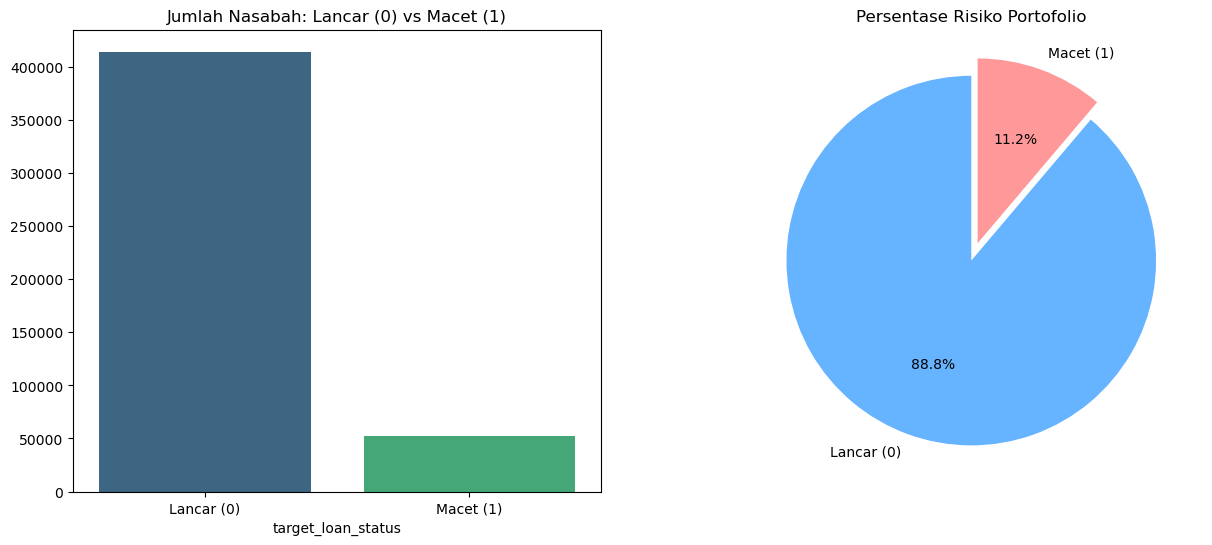

Total Nasabah Macet: 52186 orang
Persentase Macet: 11.19%


In [25]:
# Exploratory Data Analysis
# Target Distribution
import matplotlib.pyplot as plt
import seaborn as sns

counts = df['target_loan_status'].value_counts()
percent = df['target_loan_status'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(x=counts.index, y=counts.values, ax=ax[0], palette='viridis')
ax[0].set_title('Jumlah Nasabah: Lancar (0) vs Macet (1)')
ax[0].set_xticklabels(['Lancar (0)', 'Macet (1)'])
ax[1].pie(percent, labels=['Lancar (0)', 'Macet (1)'], autopct='%1.1f%%', 
        startangle=90, colors=['#66b3ff','#ff9999'], explode=(0, 0.1))
ax[1].set_title('Persentase Risiko Portofolio')

plt.show()
print(f"Total Nasabah Macet: {counts[1]} orang")
print(f"Persentase Macet: {percent[1]:.2f}%")

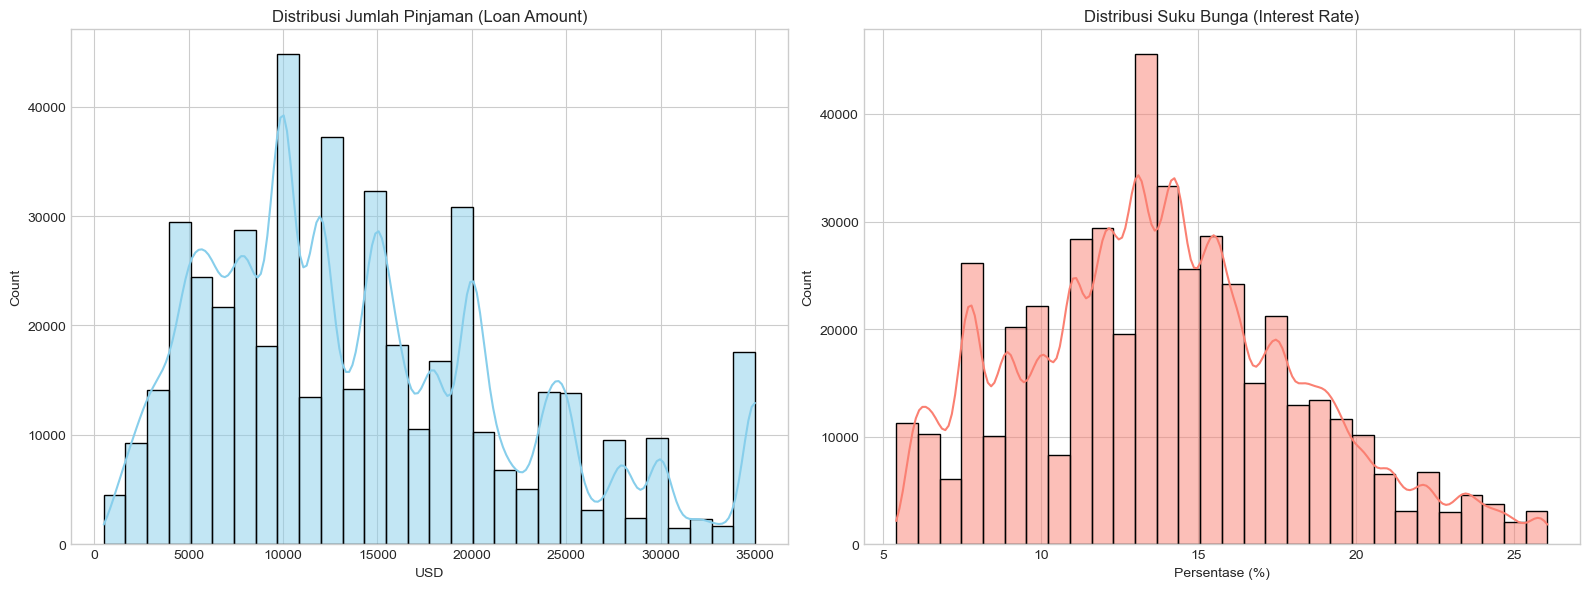

In [27]:
#Exploratory Data Analysis
#Univariat Numerik

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Histogram Jumlah Pinjaman
sns.histplot(df['loan_amnt'], bins=30, kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Distribusi Jumlah Pinjaman (Loan Amount)')
ax[0].set_xlabel('USD')

# Histogram Suku Bunga
sns.histplot(df['int_rate'], bins=30, kde=True, ax=ax[1], color='salmon')
ax[1].set_title('Distribusi Suku Bunga (Interest Rate)')
ax[1].set_xlabel('Persentase (%)')

plt.tight_layout()
plt.show()

C:\Users\khami\AppData\Local\Temp\ipykernel_22080\2565759423.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='grade', order=['A','B','C','D','E','F','G'], ax=ax[0], palette='viridis')
C:\Users\khami\AppData\Local\Temp\ipykernel_22080\2565759423.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['home_ownership'].isin(top_homes)], x='home_ownership', ax=ax[1], palette='pastel')


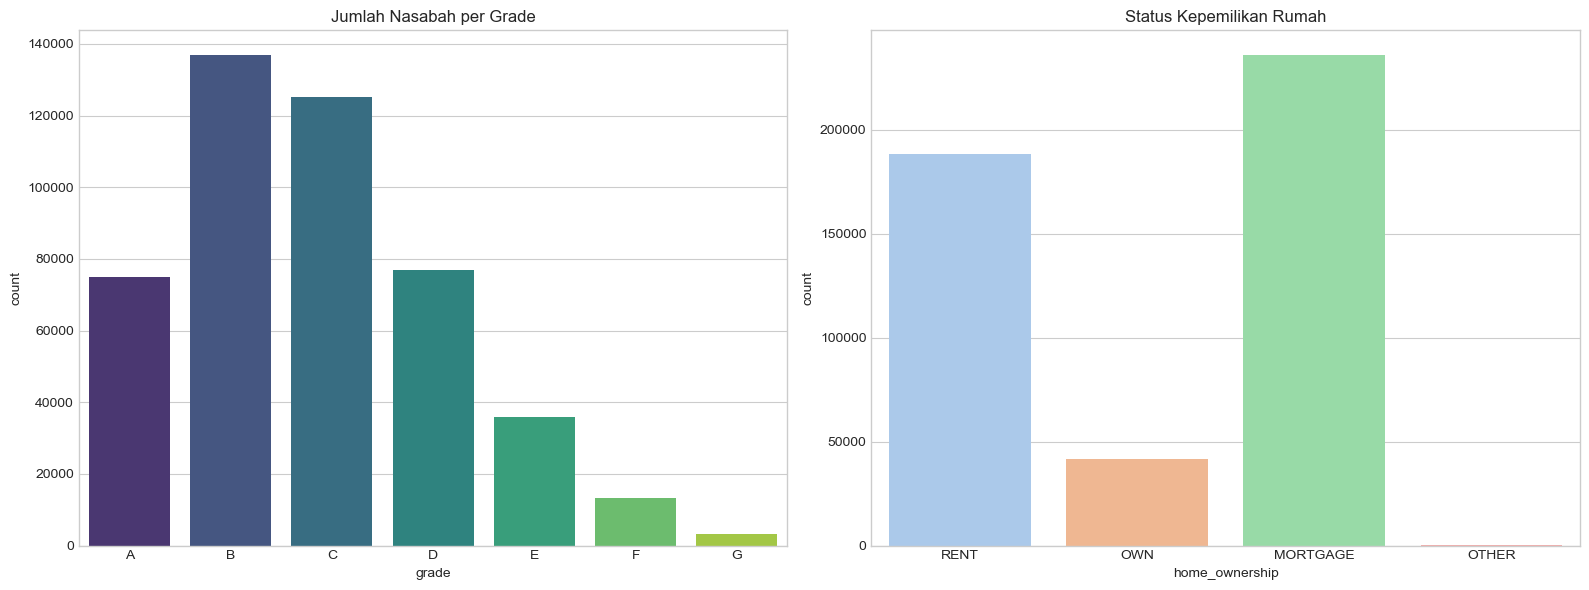

In [29]:
# Exploratory Data Analysis
# Univariat Kategorikal
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Countplot untuk Grade
sns.countplot(data=df, x='grade', order=['A','B','C','D','E','F','G'], ax=ax[0], palette='viridis')
ax[0].set_title('Jumlah Nasabah per Grade')

# Countplot untuk Home Ownership
# Kita ambil top 4 saja agar grafik tidak kotor oleh kategori aneh (seperti ANY/NONE)
top_homes = df['home_ownership'].value_counts().head(4).index
sns.countplot(data=df[df['home_ownership'].isin(top_homes)], x='home_ownership', ax=ax[1], palette='pastel')
ax[1].set_title('Status Kepemilikan Rumah')

plt.tight_layout()
plt.show()

C:\Users\khami\AppData\Local\Temp\ipykernel_22080\685427860.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='grade', y='target_loan_status', data=risk_per_grade,


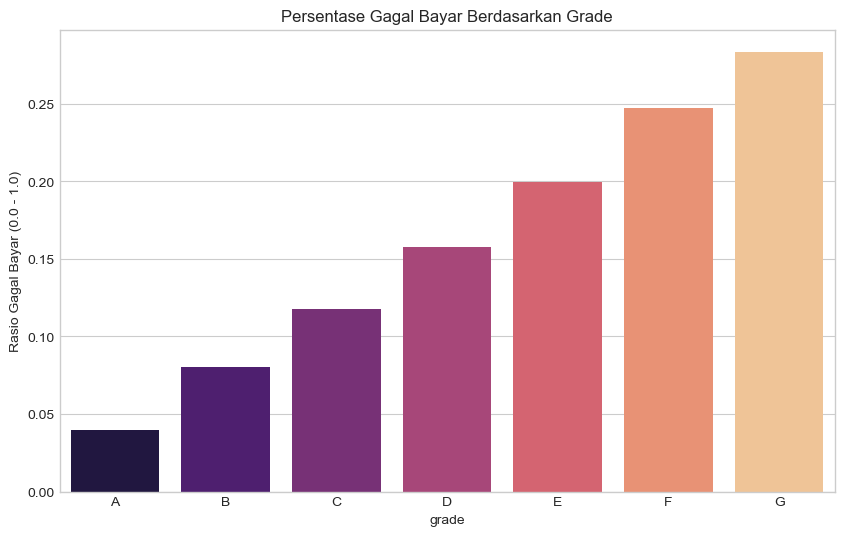

In [31]:
# Exploratory Data Analysis
# Bivariate Analysis
# Menghitung persentase gagal bayar di setiap Grade
risk_per_grade = df.groupby('grade')['target_loan_status'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='grade', y='target_loan_status', data=risk_per_grade, 
            order=['A','B','C','D','E','F','G'], palette='magma')

plt.title('Persentase Gagal Bayar Berdasarkan Grade')
plt.ylabel('Rasio Gagal Bayar (0.0 - 1.0)')
plt.show()

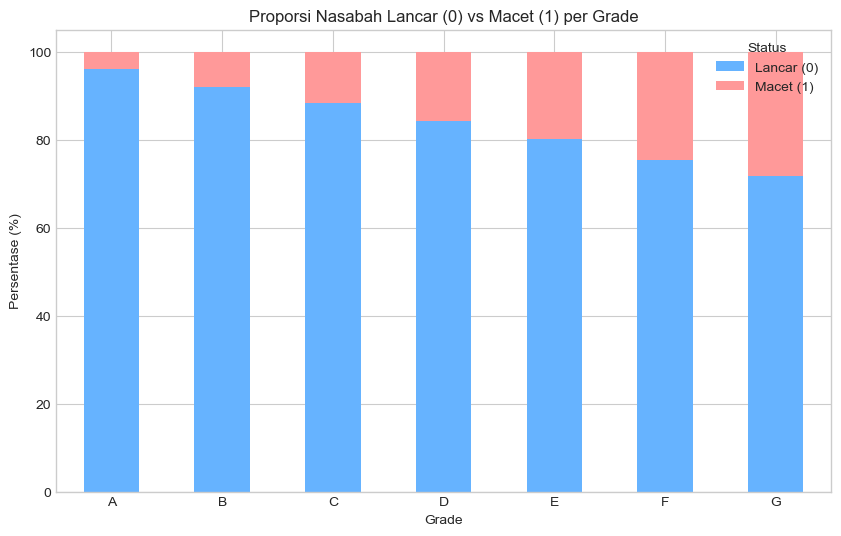

In [33]:
#Exploratory Data Analysis
# Bivariate Analysis
df_ct = pd.crosstab(df['grade'], df['target_loan_status'], normalize='index') * 100
df_ct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#66b3ff','#ff9999'])

plt.title('Proporsi Nasabah Lancar (0) vs Macet (1) per Grade')
plt.xlabel('Grade')
plt.ylabel('Persentase (%)')
plt.legend(title='Status', labels=['Lancar (0)', 'Macet (1)'], loc='upper right')
plt.xticks(rotation=0)
plt.show()

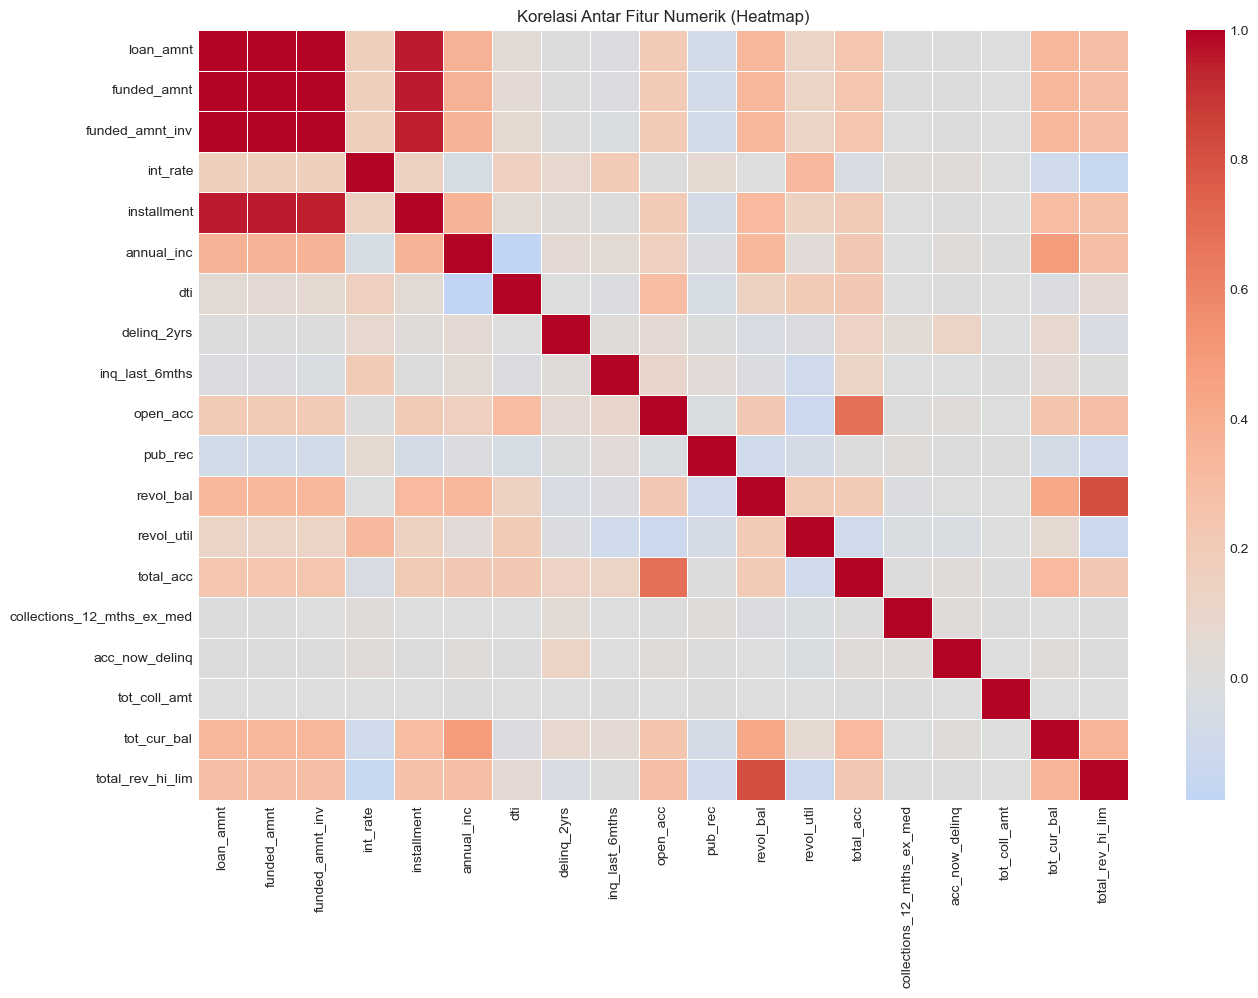

In [35]:
#Exploratory Data Analysis
#Korelasi Analysis
plt.figure(figsize=(15, 10))
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr()

# Gambar Heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Korelasi Antar Fitur Numerik (Heatmap)')
plt.show()

C:\Users\khami\AppData\Local\Temp\ipykernel_22080\361269614.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')


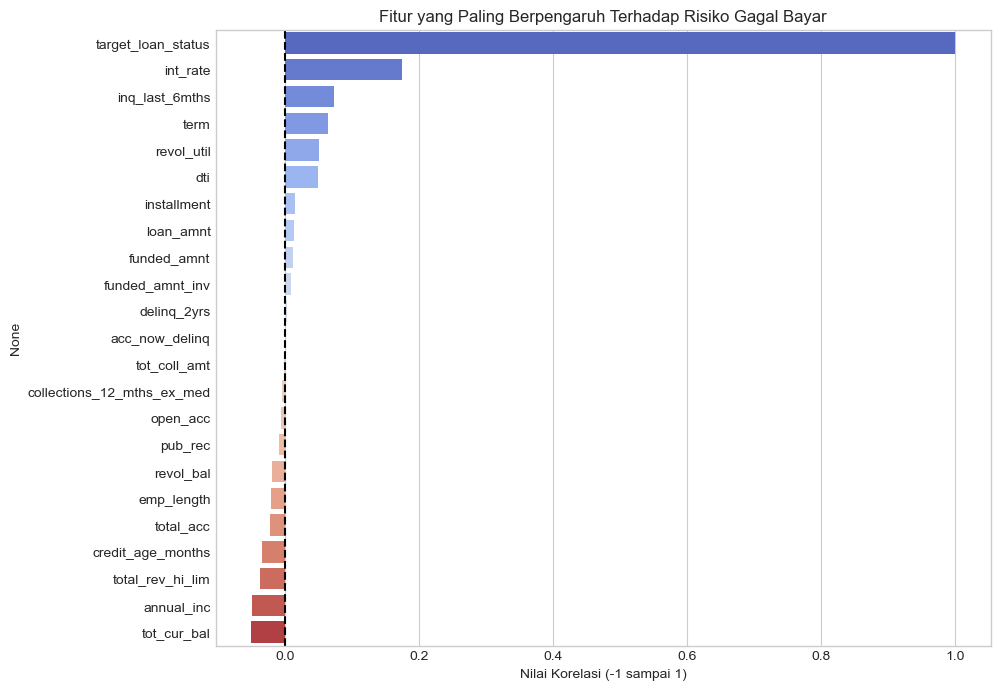

In [37]:
# Exploratory Data Analysis
# Korelasi Analysis
# Korelasi Target

bad_status = ['Charged Off', 'Default', 'Late (31-120 days)', 'Late (16-30 days)', 'Does not meet the credit policy. Status:Charged Off']
df['target_loan_status'] = np.where(df['loan_status'].isin(bad_status), 1, 0)
df_numeric = df.select_dtypes(include=[np.number])
correlations = df_numeric.corr()['target_loan_status'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=correlations.values, y=correlations.index, palette='coolwarm')

plt.title('Fitur yang Paling Berpengaruh Terhadap Risiko Gagal Bayar')
plt.axvline(x=0, color='black', linestyle='--') # Garis tengah
plt.xlabel('Nilai Korelasi (-1 sampai 1)')
plt.show()

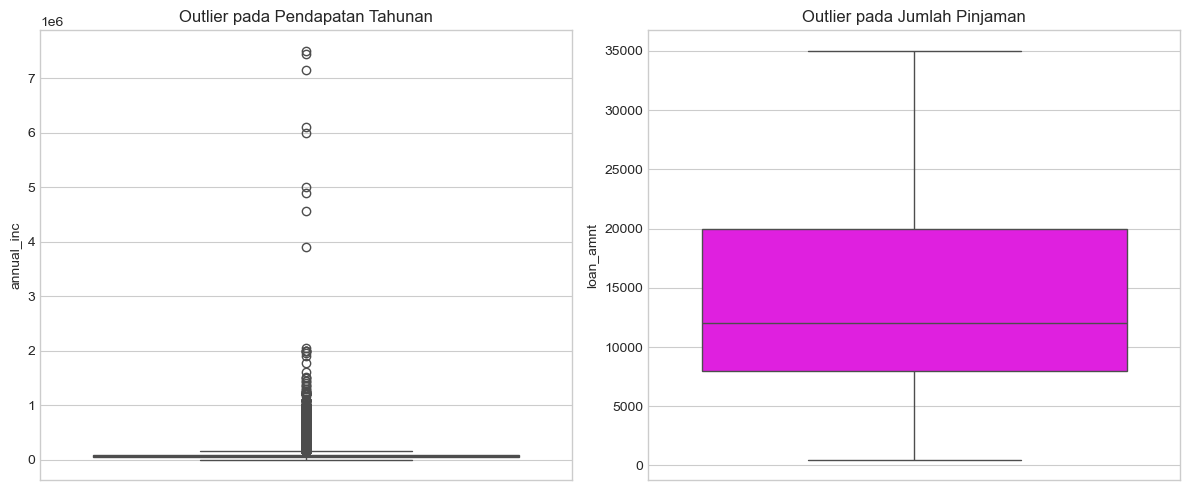

In [39]:
#Exploratory Data Analysis
#Outlier
plt.figure(figsize=(12, 5))

# Cek Outlier di Annual Income (Seringkali banyak data ekstrem di sini)
plt.subplot(1, 2, 1)
sns.boxplot(y=df['annual_inc'], color='cyan')
plt.title('Outlier pada Pendapatan Tahunan')

# Cek Outlier di Loan Amount
plt.subplot(1, 2, 2)
sns.boxplot(y=df['loan_amnt'], color='magenta')
plt.title('Outlier pada Jumlah Pinjaman')

plt.tight_layout()
plt.show()

In [41]:
# Feature Engineering
# Pembuatan fitur baru
import numpy as np

# Financial Ratios
df['inst_to_inc_ratio'] = df['installment'] / ((df['annual_inc'] / 12) + 1)
df['utilization_ratio'] = df['revol_bal'] / (df['total_rev_hi_lim'] + 1)
df['loan_to_inc_ratio'] = df['loan_amnt'] / (df['annual_inc'] + 1)

# Time-Based Features
df['credit_age_years'] = df['credit_age_months'] / 12

# Interaction Features 
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade_int_interaction'] = df['grade'].map(grade_map) * df['int_rate']


new_cols = ['inst_to_inc_ratio', 'utilization_ratio', 'loan_to_inc_ratio', 'credit_age_years', 'grade_int_interaction']
df[new_cols] = df[new_cols].replace([np.inf, -np.inf], np.nan)

df['inst_to_inc_ratio'] = df['inst_to_inc_ratio'].fillna(0)
df['utilization_ratio'] = df['utilization_ratio'].fillna(0)
df['loan_to_inc_ratio'] = df['loan_to_inc_ratio'].fillna(0)
df['credit_age_years'] = df['credit_age_years'].fillna(df['credit_age_years'].median())
df['grade_int_interaction'] = df['grade_int_interaction'].fillna(0)

print("Fitur baru berhasil dibuat dan dibersihkan dari nilai Infinite/NaN!")

Fitur baru berhasil dibuat dan dibersihkan dari nilai Infinite/NaN!


In [43]:
# List fitur baru yang tadi dibuat
new_features = ['inst_to_inc_ratio', 'utilization_ratio', 'loan_to_inc_ratio', 'credit_age_years', 'grade_int_interaction']

# Hitung korelasi fitur baru terhadap target (asumsi kolom target bernama 'loan_status' atau 'target')
# Ganti 'target' dengan nama kolom targetmu
correlations = df[new_features + ['target_loan_status']].corr()['target_loan_status'].sort_values(ascending=False)

print("Korelasi Fitur Baru terhadap Target:")
print(correlations)

Korelasi Fitur Baru terhadap Target:
target_loan_status       1.000000
grade_int_interaction    0.169427
inst_to_inc_ratio        0.084145
loan_to_inc_ratio        0.080004
utilization_ratio       -0.011872
credit_age_years        -0.033512
Name: target_loan_status, dtype: float64


In [45]:
# Feature Engineering
#handling missing value
missing_values = df.isnull().mean() * 100
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Daftar Kolom dengan Data Kosong (%):")
print(missing_values)

Daftar Kolom dengan Data Kosong (%):
tot_coll_amt                  15.071469
tot_cur_bal                   15.071469
total_rev_hi_lim              15.071469
revol_util                     0.072917
collections_12_mths_ex_med     0.031097
delinq_2yrs                    0.006219
inq_last_6mths                 0.006219
open_acc                       0.006219
pub_rec                        0.006219
total_acc                      0.006219
acc_now_delinq                 0.006219
annual_inc                     0.000858
dtype: float64


In [47]:
#Feature Engineering
#handling missing value
# Isi dengan Median 
cols_to_fix = ['tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim']
for col in cols_to_fix:
    df[col] = df[col].fillna(df[col].median())
    
# Hapus baris 
remaining_nan_cols = df.columns[df.isnull().any()].tolist()
df.dropna(subset=remaining_nan_cols, inplace=True)

print("Sisa Data Kosong:")
print(df.isnull().sum().sum())

Sisa Data Kosong:
0


Capping annual_inc di batas: 243000.00
Capping inst_to_inc_ratio di batas: 0.18
Capping loan_to_inc_ratio di batas: 0.46
Capping utilization_ratio di batas: 0.98
Capping tot_cur_bal di batas: 620601.22


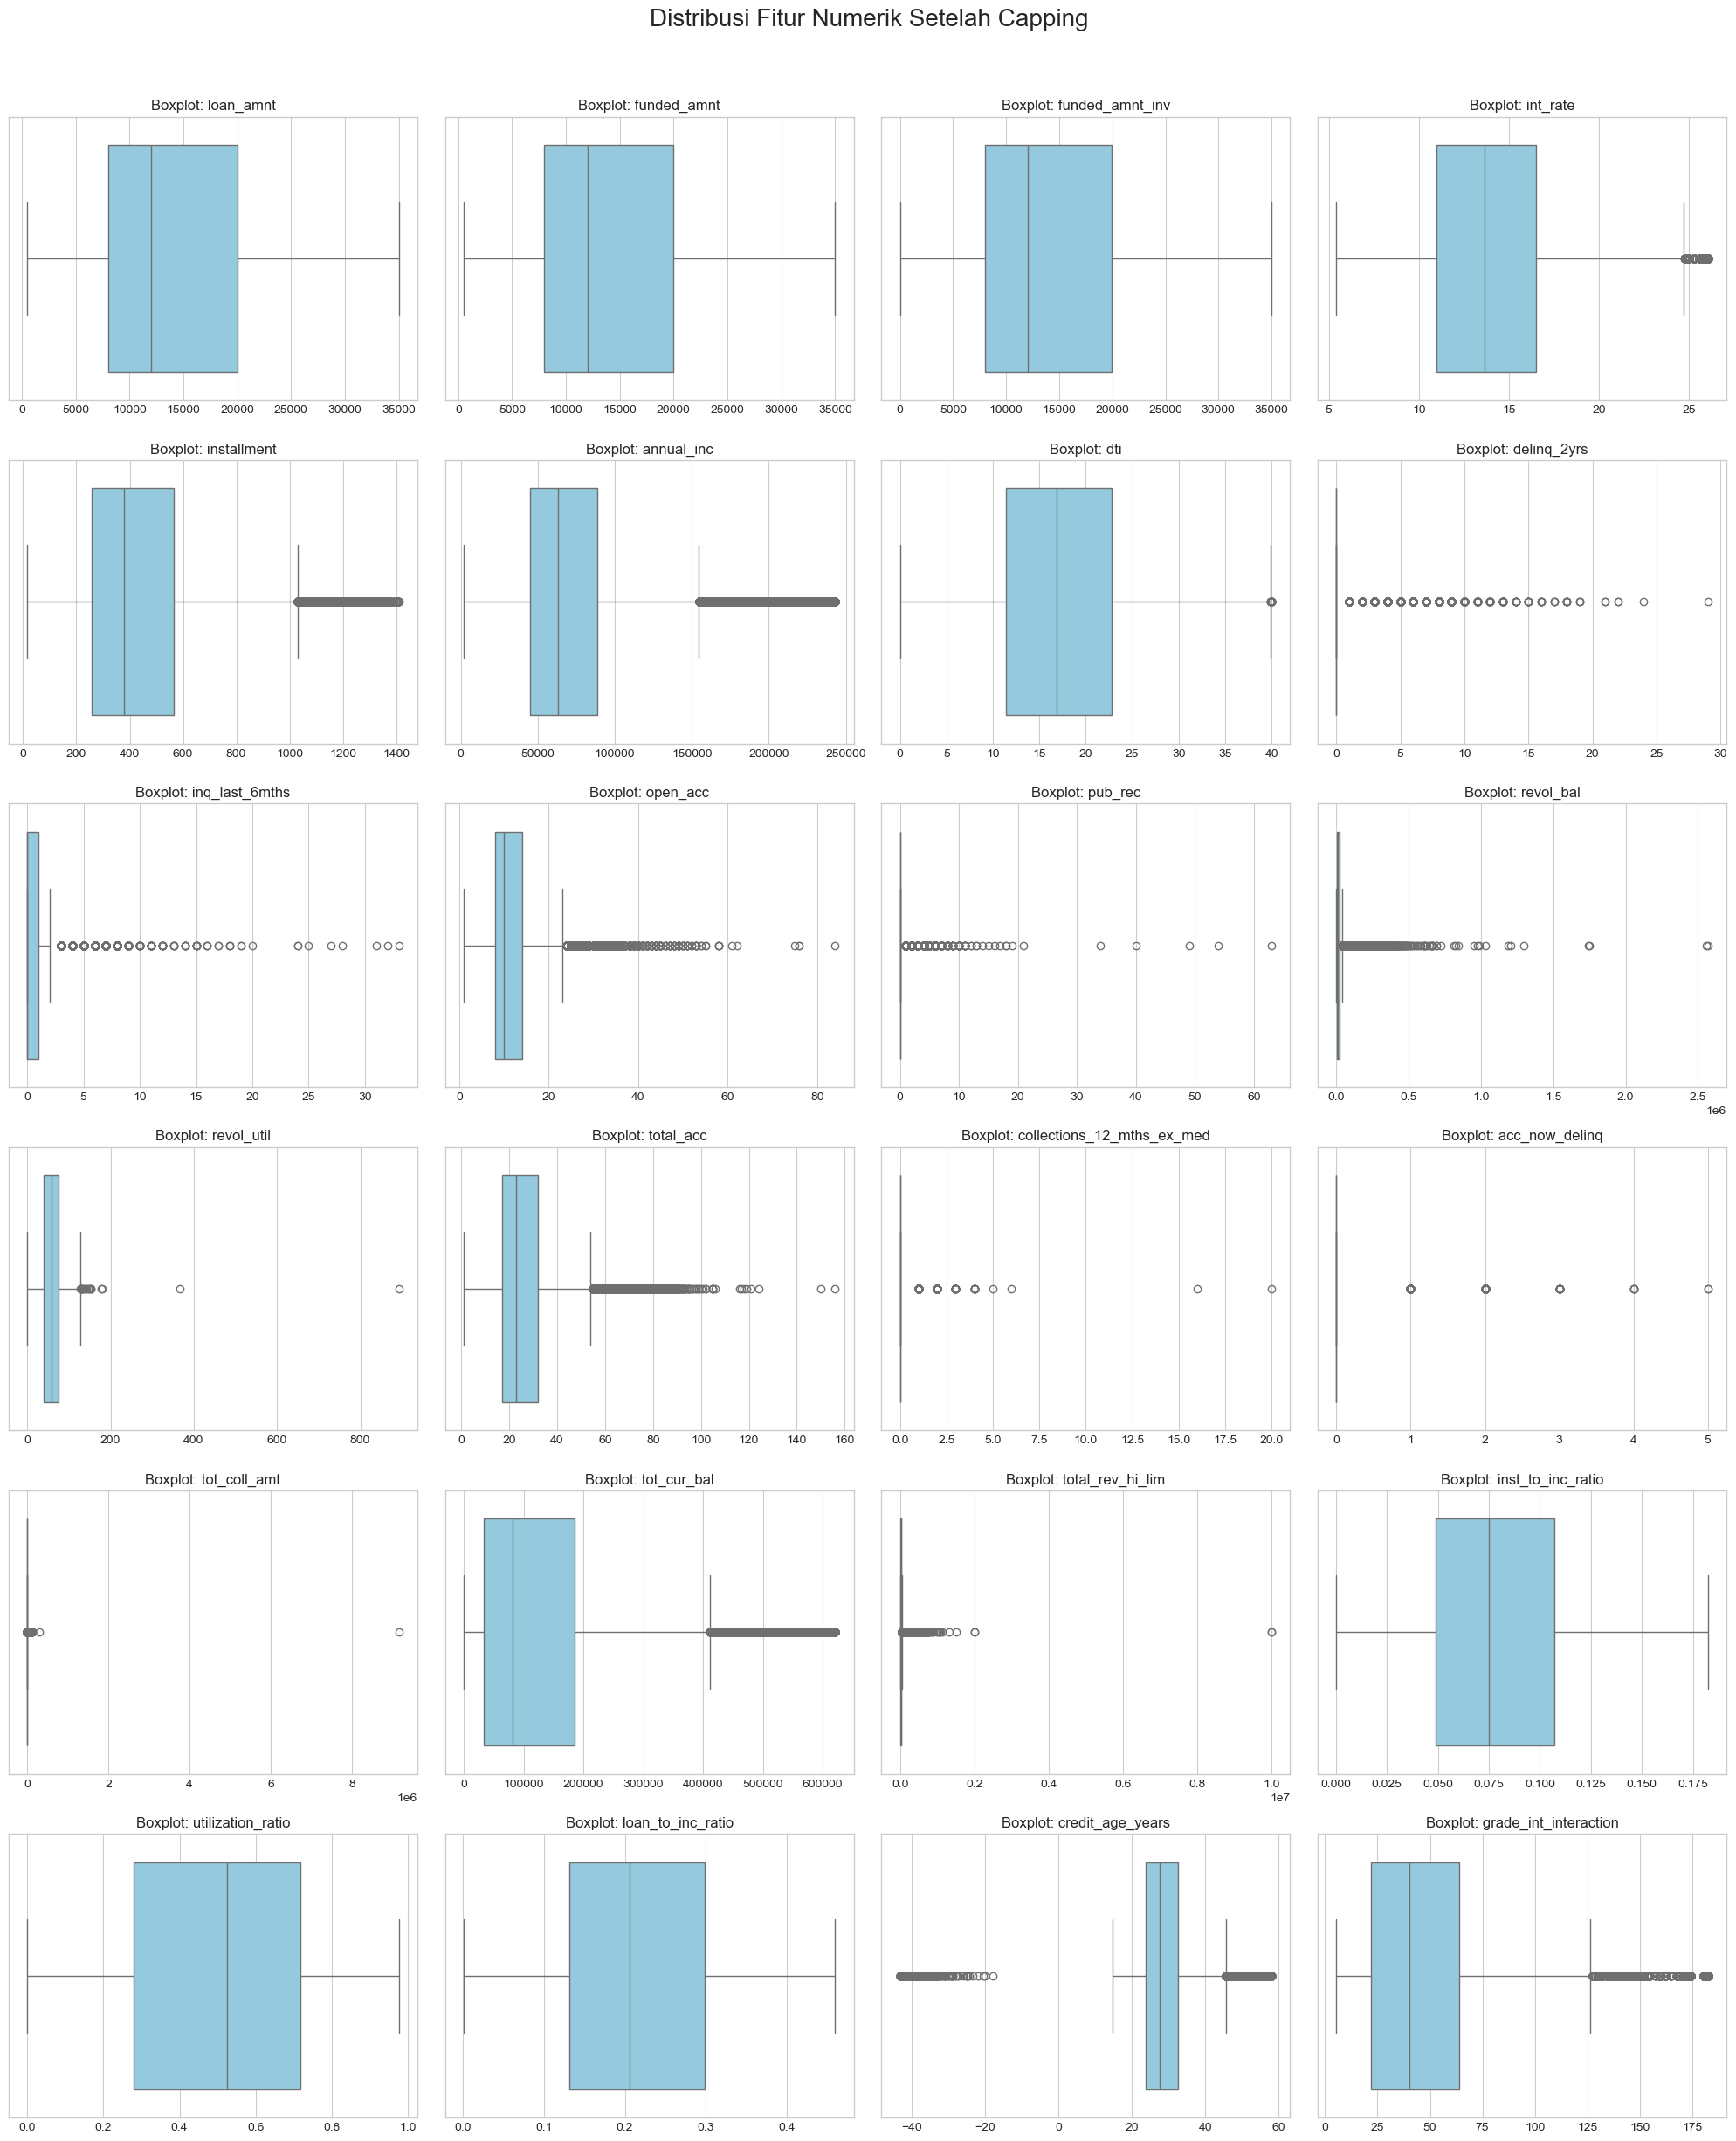

In [49]:
# Feature Engineering
# Handling Outlier (Capping)

cols_to_cap = ['annual_inc', 'inst_to_inc_ratio', 'loan_to_inc_ratio', 'utilization_ratio', 'tot_cur_bal']

for col in cols_to_cap:
    if col in df.columns:
        upper_limit = df[col].quantile(0.99)
        df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])
        print(f"Capping {col} di batas: {upper_limit:.2f}")

import matplotlib.pyplot as plt
import seaborn as sns
import math
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'target_loan_status' in numeric_cols:
    numeric_cols.remove('target_loan_status')

n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
fig.suptitle('Distribusi Fitur Numerik Setelah Capping', fontsize=20, y=1.02)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot: {col}', fontsize=12)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [51]:
# Feature Engineering
# Drop kolom redundant

redundant_after_fe = ['funded_amnt', 'funded_amnt_inv', 'installment']
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
cols_to_drop_final = redundant_after_fe + constant_cols
df.drop(columns=cols_to_drop_final, axis=1, inplace=True, errors='ignore')

print(f"Berhasil membuang {len(cols_to_drop_final)} kolom redundant/konstan.")
print(f"Sisa kolom sekarang: {len(df.columns)}")

Berhasil membuang 4 kolom redundant/konstan.
Sisa kolom sekarang: 34


In [53]:
# Feature Engineering
# Encoding
# Mapping Manual (Ordinal)
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
if 'grade' in df.columns:
    df['grade'] = df['grade'].map(grade_map)

if 'loan_status' in df.columns:
    df = df.drop(columns=['loan_status'])
    print("Kolom 'loan_status' berhasil dihapus.")

cat_cols = df.select_dtypes(include=['object']).columns.tolist()

target_col = 'target_loan_status' 
if target_col in cat_cols:
    cat_cols.remove(target_col)

# One-Hot Encoding
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

print("\n--- Encoding Berhasil! ---")
print(f"Bentuk data final: {df.shape}")
print(f"Daftar kolom yang di-One-Hot: {cat_cols}")

Kolom 'loan_status' berhasil dihapus.

--- Encoding Berhasil! ---
Bentuk data final: (465832, 131)
Daftar kolom yang di-One-Hot: ['sub_grade', 'home_ownership', 'verification_status', 'pymnt_plan', 'purpose', 'addr_state', 'initial_list_status']


In [55]:
#Modelling
# Split Data
from sklearn.model_selection import train_test_split

# Menenentukan Fitur (X) dan Target (y)
X = df.drop(columns=['loan_status', 'target_loan_status'], errors='ignore')
y = df['target_loan_status']

# Split pertama
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split kedua
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("--- PEMBAGIAN DATA ---")
print(f"X_train: {X_train.shape}")
print(f"X_val  : {X_val.shape}")
print(f"X_test : {X_test.shape}")
print(f"Fitur  : {X_train.shape[1]}")

--- PEMBAGIAN DATA ---
X_train: (279498, 130)
X_val  : (93167, 130)
X_test : (93167, 130)
Fitur  : 130


--- DISTRIBUSI TARGET (DATA TRAIN) ---
Lancar (0): 248236 nasabah (88.81%)
Macet (1) : 31262 nasabah (11.19%)


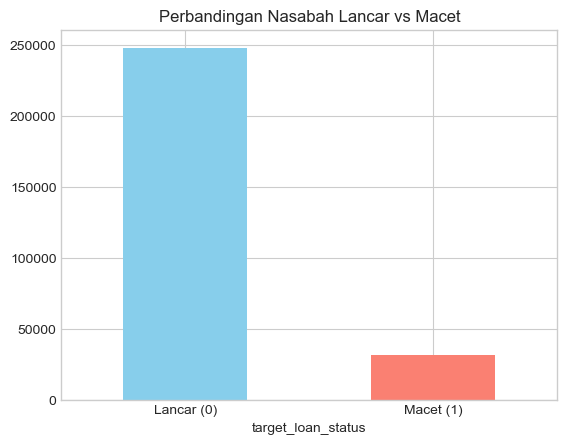

In [57]:
# Modelling
# Imbalance data
target_counts = y_train.value_counts()
target_percent = y_train.value_counts(normalize=True) * 100

print("--- DISTRIBUSI TARGET (DATA TRAIN) ---")
print(f"Lancar (0): {target_counts[0]} nasabah ({target_percent[0]:.2f}%)")
print(f"Macet (1) : {target_counts[1]} nasabah ({target_percent[1]:.2f}%)")

# Visualisasi sederhana
import matplotlib.pyplot as plt
target_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Perbandingan Nasabah Lancar vs Macet')
plt.xticks([0, 1], ['Lancar (0)', 'Macet (1)'], rotation=0)
plt.show()

Sedang melatih Logistic Regression (Balanced)...


C:\Users\khami\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



HASIL EVALUASI: LOGISTIC REGRESSION
ROC-AUC Score: 0.6661

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.64      0.76     82746
           1       0.17      0.60      0.27     10421

    accuracy                           0.64     93167
   macro avg       0.55      0.62      0.51     93167
weighted avg       0.84      0.64      0.70     93167


Menampilkan Confusion Matrix...


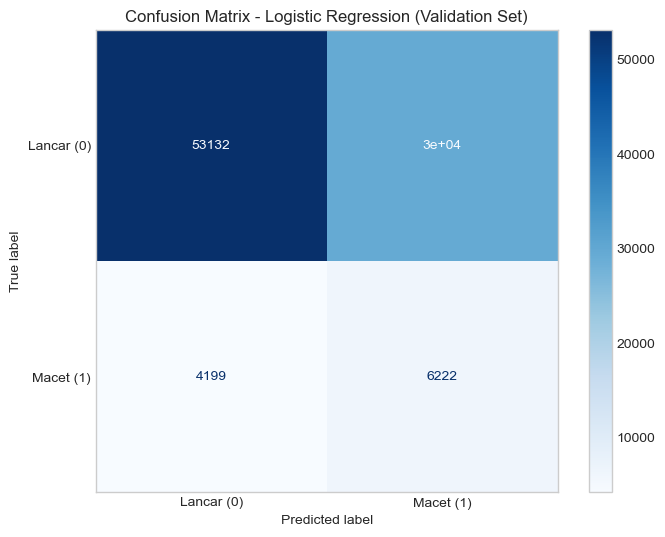

In [59]:
#Modelling
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, 
    confusion_matrix, 
    classification_report, 
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Inisialisasi & Training Model
print("Sedang melatih Logistic Regression (Balanced)...")
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train, y_train)

# Prediksi
y_pred_logreg = logreg.predict(X_val)
y_prob_logreg = logreg.predict_proba(X_val)[:, 1]

# Output Evaluasi 
print("\n" + "="*30)
print("HASIL EVALUASI: LOGISTIC REGRESSION")
print("="*30)
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_prob_logreg):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_logreg))

# Visualisasi
print("\nMenampilkan Confusion Matrix...")
cm = confusion_matrix(y_val, y_pred_logreg)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Lancar (0)', 'Macet (1)'])
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix - Logistic Regression (Validation Set)')
plt.grid(False) 
plt.show()

In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Membuat Pipeline (StandardScaler + LogisticRegression)
logreg_scaled = make_pipeline(
    StandardScaler(), 
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
)

print("Sedang melatih Logistic Regression DENGAN SCALER...")
logreg_scaled.fit(X_train, y_train)

# Prediksi pada X_val
y_prob_scaled = logreg_scaled.predict_proba(X_val)[:, 1]
print(f"ROC-AUC Baru (Dengan Scaler): {roc_auc_score(y_val, y_prob_scaled):.4f}")

Sedang melatih Logistic Regression DENGAN SCALER...
ROC-AUC Baru (Dengan Scaler): 0.6929



HASIL EVALUASI: LOGISTIC REGRESSION (WITH SCALER)
ROC-AUC Score: 0.6929

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.62      0.74     82746
           1       0.18      0.66      0.28     10421

    accuracy                           0.62     93167
   macro avg       0.56      0.64      0.51     93167
weighted avg       0.85      0.62      0.69     93167


Menampilkan Confusion Matrix...


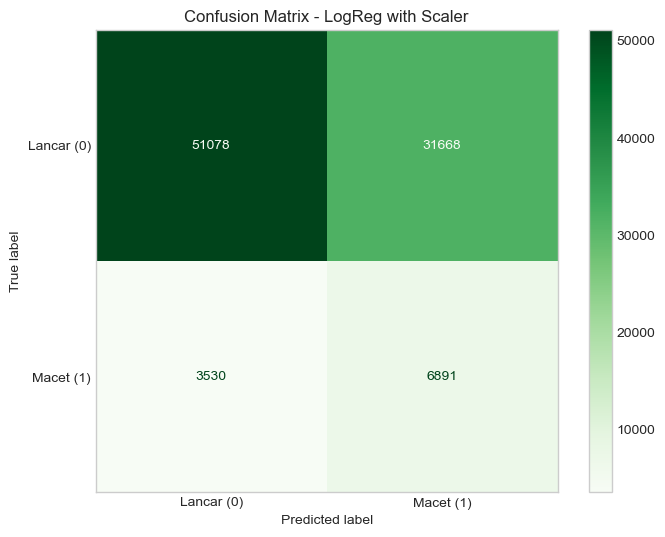

In [65]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt

# 1. Pastikan Prediksi menggunakan model yang sudah di-Scaler
# (Gunakan y_prob_scaled dan y_pred_scaled dari model logreg_scaled kamu)
y_pred_scaled = logreg_scaled.predict(X_val)
y_prob_scaled = logreg_scaled.predict_proba(X_val)[:, 1]

# 2. Output Evaluasi 
print("\n" + "="*40)
print("HASIL EVALUASI: LOGISTIC REGRESSION (WITH SCALER)")
print("="*40)
auc_final = roc_auc_score(y_val, y_prob_scaled)
print(f"ROC-AUC Score: {auc_final:.4f}")

# Jika AUC masih 1.0000, print fitur yang paling mencurigakan
if auc_final > 0.99:
    print("\n⚠️ PERINGATAN: Skor terlalu sempurna! Kemungkinan ada Data Leakage.")
    # Menampilkan fitur yang korelasinya terlalu tinggi dengan target
    correlations = X_train.corrwith(y_train).sort_values(ascending=False)
    print("\nTop 5 Fitur dengan korelasi tertinggi (Cek apakah ada 'loan_status'):")
    print(correlations.head(5))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_scaled))

# 3. Visualisasi Confusion Matrix
print("\nMenampilkan Confusion Matrix...")
cm = confusion_matrix(y_val, y_pred_scaled)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Lancar (0)', 'Macet (1)'])
disp.plot(cmap='Greens', ax=ax) # Warna hijau untuk membedakan dengan yang tanpa scaler
plt.title('Confusion Matrix - LogReg with Scaler')
plt.grid(False)
plt.show()

Sedang melatih Random Forest (Balanced)...

HASIL EVALUASI: RANDOM FOREST
ROC-AUC Score: 0.6913

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.62      0.75     82746
           1       0.18      0.65      0.28     10421

    accuracy                           0.63     93167
   macro avg       0.56      0.64      0.51     93167
weighted avg       0.85      0.63      0.70     93167


Menampilkan Confusion Matrix...


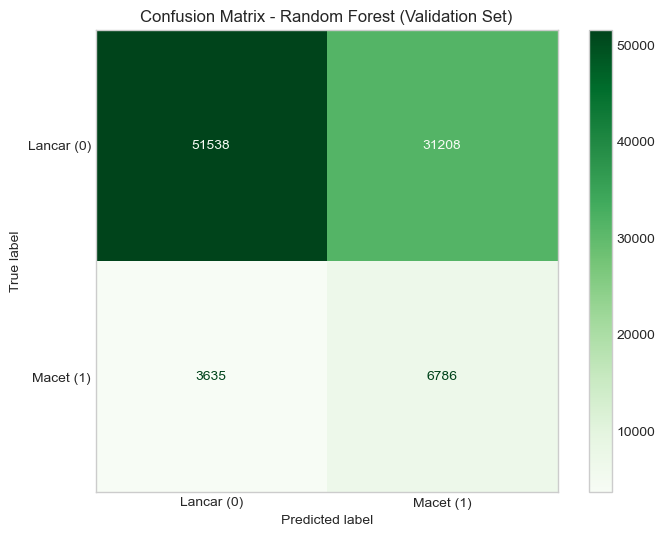

In [67]:
# Modelling
# Random Forest
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi & Training Model
print("Sedang melatih Random Forest (Balanced)...")
rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Prediksi
y_pred_rf = rf.predict(X_val)
y_prob_rf = rf.predict_proba(X_val)[:, 1]

# Output Evaluasi 
print("\n" + "="*30)
print("HASIL EVALUASI: RANDOM FOREST")
print("="*30)
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_prob_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_rf))

# Visualisasi Confusion Matrix
print("\nMenampilkan Confusion Matrix...")
cm = confusion_matrix(y_val, y_pred_rf)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Lancar (0)', 'Macet (1)'])
disp.plot(cmap='Greens', ax=ax) # Warna hijau biar beda sama LogReg
plt.title('Confusion Matrix - Random Forest (Validation Set)')
plt.grid(False)
plt.show()

Sedang melatih XGBoost (Balanced)...


C:\Users\khami\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:45:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



HASIL EVALUASI: XGBOOST
ROC-AUC Score: 0.6987

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.63      0.75     82746
           1       0.18      0.66      0.29     10421

    accuracy                           0.63     93167
   macro avg       0.56      0.64      0.52     93167
weighted avg       0.85      0.63      0.70     93167


Menampilkan Confusion Matrix...


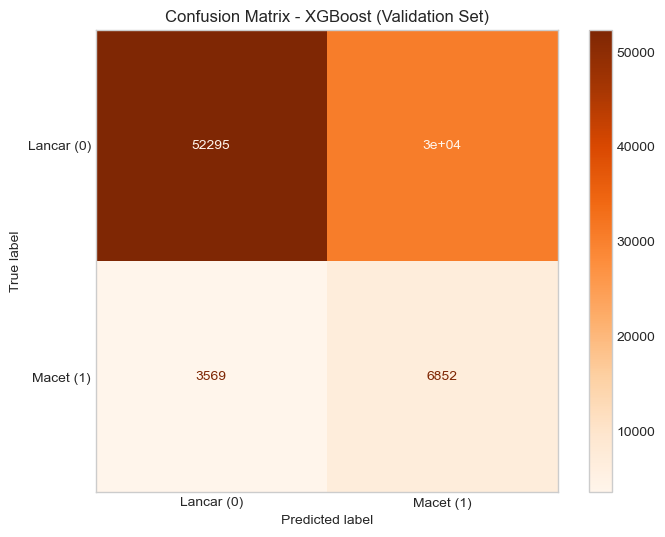

In [69]:
# Modelling
# XGBoost
from xgboost import XGBClassifier
# 1. Hitung rasio untuk penyeimbang (Lancar / Macet) dari data train
ratio = 248236 / 31262 

# 2. Inisialisasi & Training Model
print("Sedang melatih XGBoost (Balanced)...")
xgb = XGBClassifier(
    n_estimators=100, 
    scale_pos_weight=ratio, 
    learning_rate=0.1, 
    max_depth=6, 
    random_state=42, 
    use_label_encoder=False, 
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

# 3. Prediksi
y_pred_xgb = xgb.predict(X_val)
y_prob_xgb = xgb.predict_proba(X_val)[:, 1]

# 4. Output Evaluasi
print("\n" + "="*30)
print("HASIL EVALUASI: XGBOOST")
print("="*30)
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_prob_xgb):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_xgb))

# 5. Visualisasi Confusion Matrix
print("\nMenampilkan Confusion Matrix...")
cm = confusion_matrix(y_val, y_pred_xgb)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Lancar (0)', 'Macet (1)'])
disp.plot(cmap='Oranges', ax=ax) # Warna orange ciri khas XGBoost
plt.title('Confusion Matrix - XGBoost (Validation Set)')
plt.grid(False)
plt.show()

Sedang melatih LightGBM (Balanced)...

HASIL EVALUASI: LIGHTGBM
ROC-AUC Score: 0.6987

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.62      0.75     82746
           1       0.18      0.67      0.28     10421

    accuracy                           0.62     93167
   macro avg       0.56      0.64      0.51     93167
weighted avg       0.85      0.62      0.69     93167


Menampilkan Confusion Matrix...


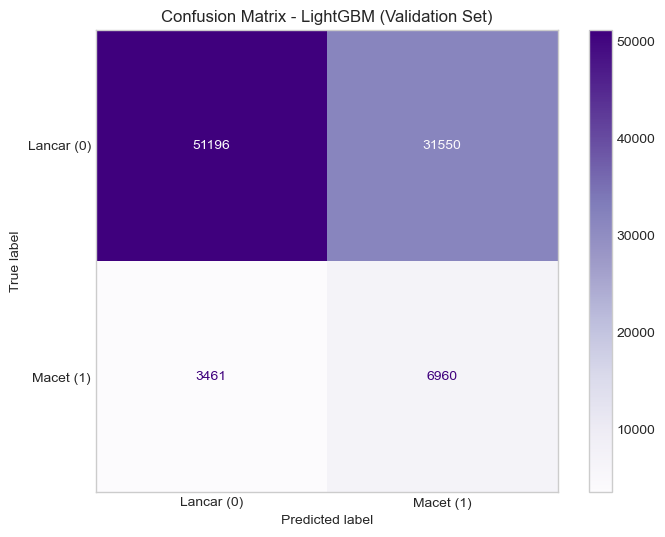

In [71]:
#Modelling
# LightGBM
from lightgbm import LGBMClassifier

ratio = 248236 / 31262 

# Inisialisasi & Training Model
print("Sedang melatih LightGBM (Balanced)...")
lgbm = LGBMClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    num_leaves=31, 
    scale_pos_weight=ratio, 
    random_state=42,
    verbose=-1
)
lgbm.fit(X_train, y_train)

# Prediksi
y_pred_lgbm = lgbm.predict(X_val)
y_prob_lgbm = lgbm.predict_proba(X_val)[:, 1]

# Output Evaluasi
print("\n" + "="*30)
print("HASIL EVALUASI: LIGHTGBM")
print("="*30)
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_prob_lgbm):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_lgbm))

# Visualisasi Confusion Matrix
print("\nMenampilkan Confusion Matrix...")
cm = confusion_matrix(y_val, y_pred_lgbm)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Lancar (0)', 'Macet (1)'])
disp.plot(cmap='Purples', ax=ax) # Warna ungu untuk LGBM
plt.title('Confusion Matrix - LightGBM (Validation Set)')
plt.grid(False)
plt.show()

In [86]:
!pip install catboost

Sedang melatih CatBoost (Balanced)...

HASIL EVALUASI: CATBOOST
ROC-AUC Score: 0.7007

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.62      0.75     82746
           1       0.18      0.67      0.29     10421

    accuracy                           0.63     93167
   macro avg       0.56      0.64      0.52     93167
weighted avg       0.85      0.63      0.70     93167


Menampilkan Confusion Matrix...


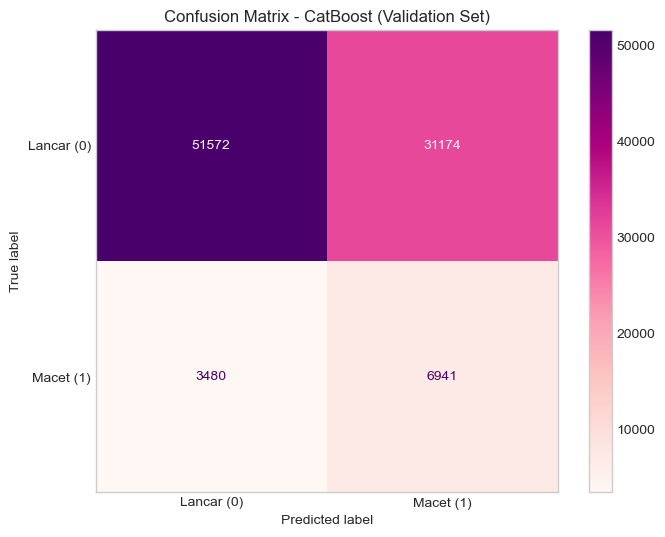

In [73]:
# Modelling
# CatBoost
from catboost import CatBoostClassifier
# Inisialisasi & Training Model
print("Sedang melatih CatBoost (Balanced)...")
cat = CatBoostClassifier(
    iterations=200, 
    learning_rate=0.1, 
    depth=6, 
    auto_class_weights='Balanced', 
    random_state=42, 
    verbose=0 # Agar tidak muncul log ribuan baris
)
cat.fit(X_train, y_train)

# Prediksi
y_pred_cat = cat.predict(X_val)
y_prob_cat = cat.predict_proba(X_val)[:, 1]

# Output Evaluasi
print("\n" + "="*30)
print("HASIL EVALUASI: CATBOOST")
print("="*30)
print(f"ROC-AUC Score: {roc_auc_score(y_val, y_prob_cat):.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred_cat))

# Visualisasi Confusion Matrix
print("\nMenampilkan Confusion Matrix...")
cm = confusion_matrix(y_val, y_pred_cat)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Lancar (0)', 'Macet (1)'])
disp.plot(cmap='RdPu', ax=ax) # Warna merah muda/pink untuk CatBoost
plt.title('Confusion Matrix - CatBoost (Validation Set)')
plt.grid(False)
plt.show()

HASIL EVALUASI FINAL: CATBOOST (DATA TEST)
Final ROC-AUC Score: 0.6985

Final Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.62      0.75     82746
           1       0.18      0.66      0.29     10421

    accuracy                           0.63     93167
   macro avg       0.56      0.64      0.52     93167
weighted avg       0.85      0.63      0.70     93167



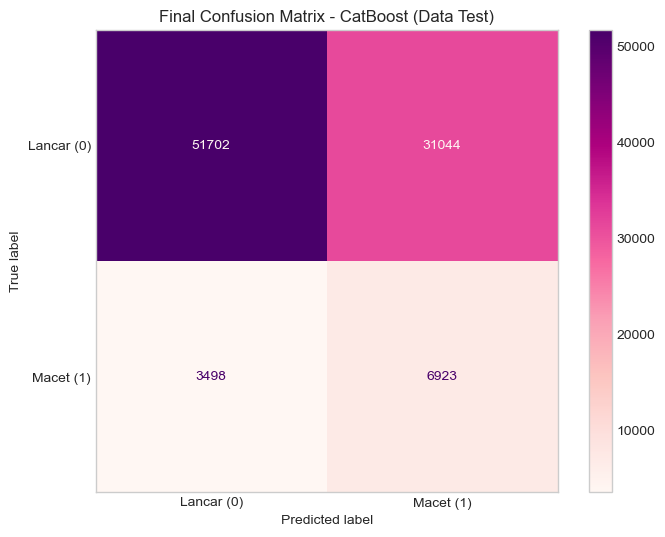

In [75]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, roc_auc_score
import matplotlib.pyplot as plt

# 1. Prediksi pada data yang benar-benar baru (X_test)
y_prob_final = cat.predict_proba(X_test)[:, 1]
y_pred_final = cat.predict(X_test)

# 2. Cetak Hasil Akhir
print("="*40)
print("HASIL EVALUASI FINAL: CATBOOST (DATA TEST)")
print("="*40)
print(f"Final ROC-AUC Score: {roc_auc_score(y_test, y_prob_final):.4f}")
print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_final))

# 3. Visualisasi Confusion Matrix Akhir
cm_final = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=['Lancar (0)', 'Macet (1)'])
disp.plot(cmap='RdPu', ax=ax)
plt.title('Final Confusion Matrix - CatBoost (Data Test)')
plt.grid(False)
plt.show()

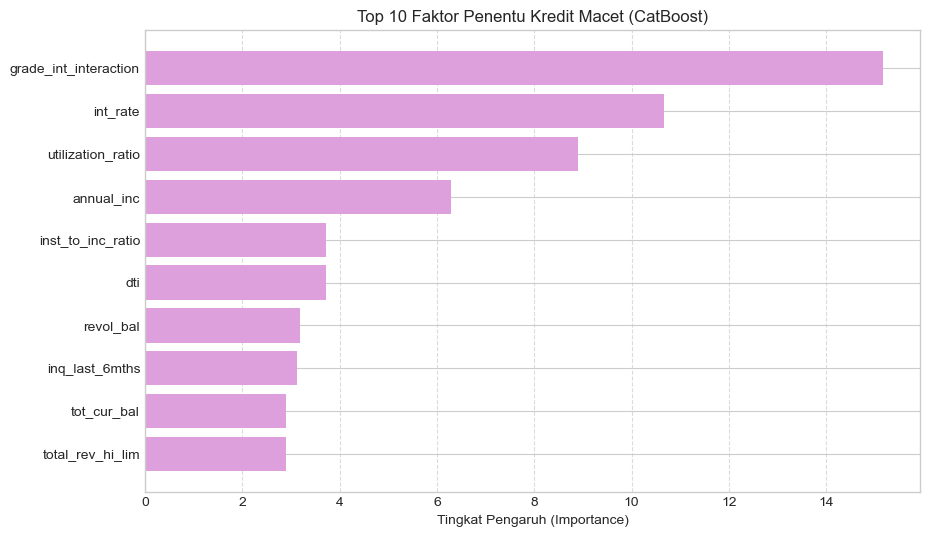

--- 5 FITUR PALING BERPENGARUH ---
                  Feature  Importance
24  grade_int_interaction   15.168590
2                int_rate   10.674983
21      utilization_ratio    8.890227
5              annual_inc    6.290309
20      inst_to_inc_ratio    3.722205


In [77]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ambil skor pentingnya fitur dari model CatBoost
feature_importance = cat.get_feature_importance()
feature_names = X_train.columns

# 2. Buat DataFrame untuk mempermudah visualisasi
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# 3. Visualisasi 10 Fitur Teratas
plt.figure(figsize=(10, 6))
plt.barh(fi_df['Feature'].head(10)[::-1], fi_df['Importance'].head(10)[::-1], color='plum')
plt.title('Top 10 Faktor Penentu Kredit Macet (CatBoost)')
plt.xlabel('Tingkat Pengaruh (Importance)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("--- 5 FITUR PALING BERPENGARUH ---")
print(fi_df.head(5))

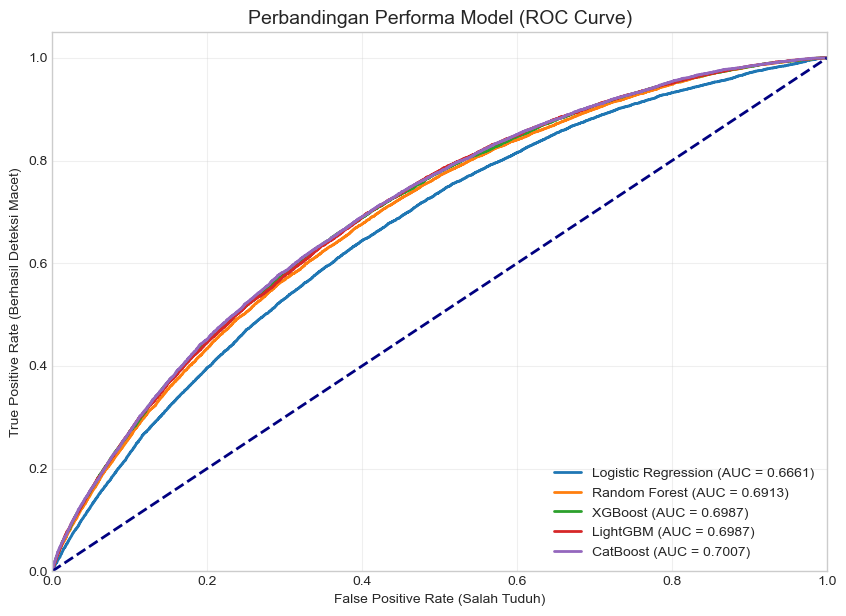

In [81]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Kumpulkan semua probabilitas model dalam dictionary
# Pastikan nama variabelnya sesuai dengan yang kamu gunakan di cell sebelumnya
models_to_plot = {
    'Logistic Regression': y_prob_logreg,
    'Random Forest': y_prob_rf,
    'XGBoost': y_prob_xgb,
    'LightGBM': y_prob_lgbm,
    'CatBoost': y_prob_cat
}

plt.figure(figsize=(10, 7))

# 2. Loop untuk menghitung dan menampilkan kurva tiap model
for name, prob in models_to_plot.items():
    fpr, tpr, _ = roc_curve(y_val, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

# 3. Tambahkan garis diagonal (Baseline/Random Guess)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# 4. Kosmetik Grafik
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Salah Tuduh)')
plt.ylabel('True Positive Rate (Berhasil Deteksi Macet)')
plt.title('Perbandingan Performa Model (ROC Curve)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()